In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pyts.decomposition import SingularSpectrumAnalysis

from analysis import (
    dominant_ssa_frequency,
    fft_spectrum,
    read_signal,
)
from config import (
    FC_HIGH,
    FC_LOW,
    INPUT_DIR,
    SAMPLING_FREQUENCY,
    SSA_CHUNKSIZE,
    SSA_COMPONENTS,
    SSA_WINDOW,
    signal_files,
)

DISPLAY_DURATION_SEC = 10.0
MAX_SAMPLES = int(DISPLAY_DURATION_SEC * SAMPLING_FREQUENCY)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Выбор исходного файла

In [2]:
FILE_STEM = "d0001"  

all_files = signal_files()
if not all_files:
    raise FileNotFoundError(
        f"В каталоге {INPUT_DIR.resolve()} не найдено файлов d####."
    )

source_path = INPUT_DIR / FILE_STEM
if not source_path.is_file():
    source_path = all_files[0]
    print(f"Файл {FILE_STEM} не найден, используем {source_path.name}")

print(f"Исходный файл: {source_path.resolve()}")
print(f"Всего файлов в датасете: {len(all_files)}")

Исходный файл: C:\IT\Fun\Furry-transform\signals\АД Дудин\d0001
Всего файлов в датасете: 827


## 1. Исходный сигнал

Для графиков: 1000 отсчётов (10 с)
Для FFT/SSA:  10000 отсчётов (100.0 с)
Диапазон амплитуд (фрагмент): [195, 270]


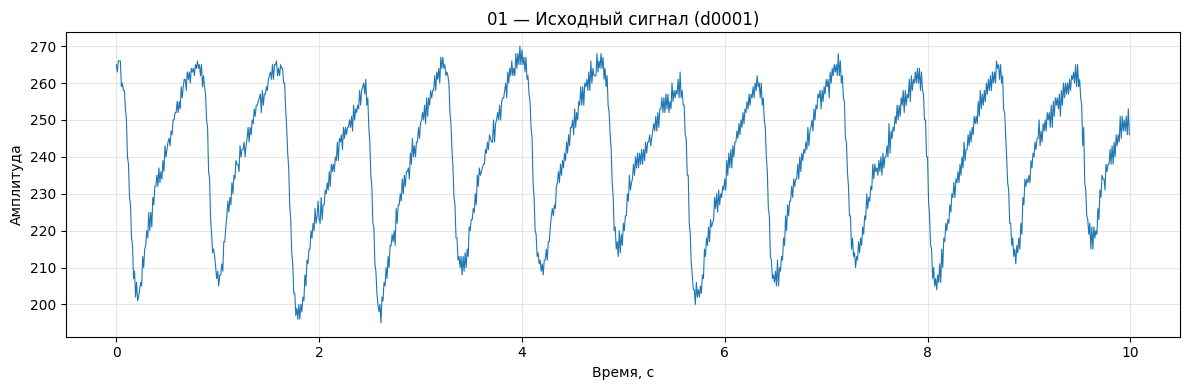

In [3]:
raw_full = np.fromfile(source_path, dtype="<i2").astype(float)
analysis_signal = read_signal(source_path)

raw_signal = raw_full[:MAX_SAMPLES]
filtered_signal = analysis_signal[:MAX_SAMPLES]
time = np.arange(raw_signal.size) / SAMPLING_FREQUENCY

print(f"Для графиков: {raw_signal.size} отсчётов ({DISPLAY_DURATION_SEC:.0f} с)")
print(f"Для FFT/SSA:  {analysis_signal.size} отсчётов ({analysis_signal.size / SAMPLING_FREQUENCY:.1f} с)")
print(f"Диапазон амплитуд (фрагмент): [{raw_signal.min():.0f}, {raw_signal.max():.0f}]")

fig, ax = plt.subplots()
ax.plot(time, raw_signal, linewidth=0.8, color="C0")
ax.set_title(f"01 — Исходный сигнал ({source_path.stem})")
ax.set_xlabel("Время, с")
ax.set_ylabel("Амплитуда")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Полосовой фильтр 0.5–5 Гц

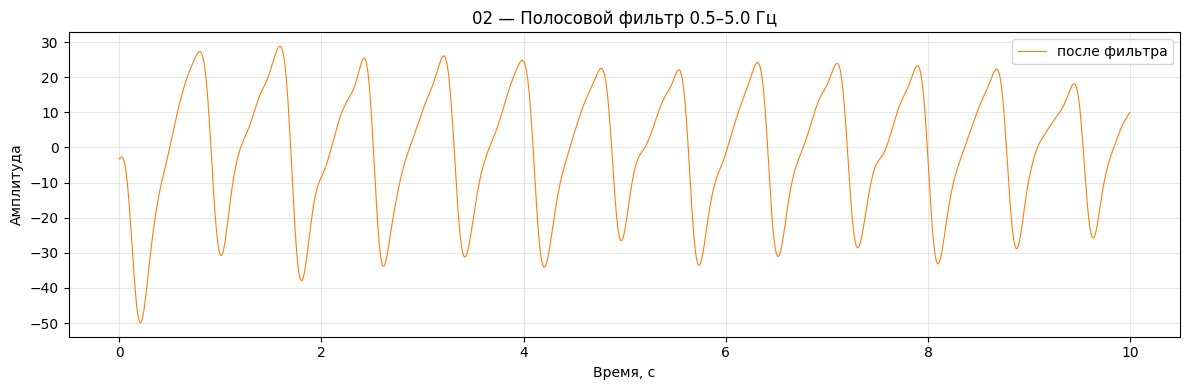

In [4]:
fig, axes = plt.subplots()

axes.plot(time, filtered_signal, linewidth=0.8, color="C1", label="после фильтра")
axes.set_xlabel("Время, с")
axes.set_ylabel("Амплитуда")
axes.set_title(f"02 — Полосовой фильтр {FC_HIGH}–{FC_LOW} Гц")
axes.grid(True, alpha=0.3)
axes.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 3. SSA - сингулярно-спектральное разложение

Размер окна SSA: 256
Компонент: 4


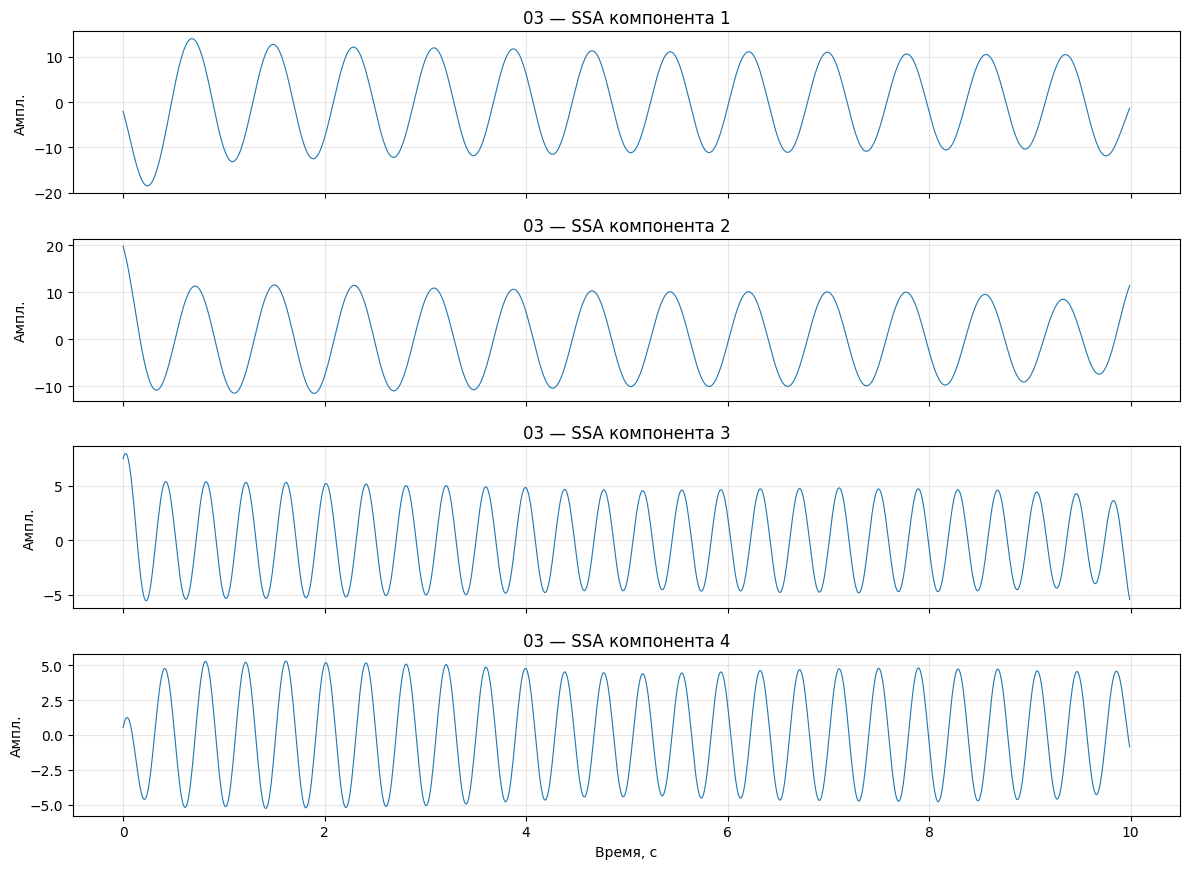

In [5]:
ssa_window = min(SSA_WINDOW, filtered_signal.size // 2)
ssa_window = max(ssa_window, 20)

groups = [[i] for i in range(SSA_COMPONENTS)]
ssa = SingularSpectrumAnalysis(
    window_size=ssa_window,
    groups=groups,
    chunksize=SSA_CHUNKSIZE,
)
decomposition = ssa.fit_transform(filtered_signal.reshape(1, -1))
ssa_components = decomposition[0] if decomposition.ndim == 3 else decomposition

print(f"Размер окна SSA: {ssa_window}")
print(f"Компонент: {len(ssa_components)}")

fig, axes = plt.subplots(len(ssa_components), 1, figsize=(12, 2.2 * len(ssa_components)), sharex=True)
if len(ssa_components) == 1:
    axes = [axes]

for index, (component, axis) in enumerate(zip(ssa_components, axes), start=1):
    axis.plot(time, component, linewidth=0.8)
    axis.set_ylabel("Ампл.")
    axis.set_title(f"03 — SSA компонента {index}")
    axis.grid(True, alpha=0.3)

axes[-1].set_xlabel("Время, с")
plt.tight_layout()
plt.show()

## 4. FFT - спектр сигнала

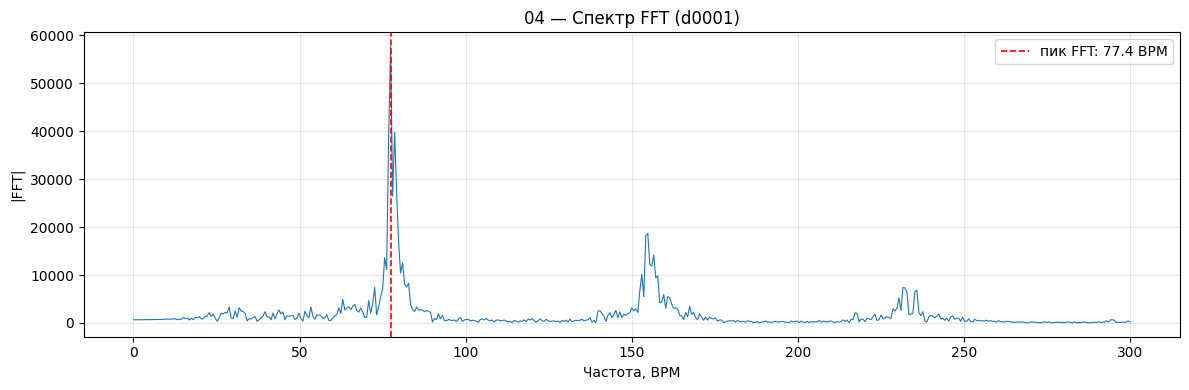

In [6]:
fft_hz, freqs, magnitudes = fft_spectrum(analysis_signal)
fft_bpm = fft_hz * 60

mask = freqs <= FC_LOW

fig, ax = plt.subplots()
ax.plot(freqs[mask] * 60, magnitudes[mask], linewidth=0.8, color="C0")
ax.axvline(fft_bpm, color="r", linestyle="--", linewidth=1.2, label=f"пик FFT: {fft_bpm:.1f} BPM")
ax.set_title(f"04 — Спектр FFT ({source_path.stem})")
ax.set_xlabel("Частота, BPM")
ax.set_ylabel("|FFT|")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Сравнение FFT и SSA

In [ ]:
ssa_window = max(min(SSA_WINDOW, analysis_signal.size // 2), 20)

ssa_hz = dominant_ssa_frequency(
    analysis_signal
)
ssa_bpm = ssa_hz * 60

print(f"Файл:           {source_path.name}")
print(f"Частота FFT:    {fft_hz:.3f} Гц  →  {fft_bpm:.1f} BPM")
print(f"Частота SSA:    {ssa_hz:.3f} Гц  →  {ssa_bpm:.1f} BPM")
print(f"Разница:        {abs(fft_bpm - ssa_bpm):.1f} BPM")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter([fft_bpm], [ssa_bpm], s=80, zorder=3)
lo = min(fft_bpm, ssa_bpm) - 5
hi = max(fft_bpm, ssa_bpm) + 5
ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Частота FFT, BPM")
ax.set_ylabel("Частота SSA, BPM")
ax.set_title(f"Сравнение для {source_path.stem}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()